In [1]:
# =====================================================================
# Drug Dose-Response Dashboard (BBBC021, plate Week4_27481)
# One cell: download -> count nuclei -> viability -> stats -> verdicts -> dashboard
# =====================================================================
!pip install -q scikit-image pandas numpy matplotlib scipy gradio tifffile tqdm

import os, zipfile
import numpy as np, pandas as pd, tifffile
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage import filters, measure, morphology, segmentation
from scipy import ndimage as ndi
from scipy.optimize import curve_fit
from scipy.stats import mannwhitneyu
import gradio as gr

BASE = "https://data.broadinstitute.org/bbbc/BBBC021/"
PLATE = "Week4_27481"
CHOSEN = ["5-fluorouracil", "AG-1478", "anisomycin",
          "indirubin monoxime", "olomoucine", "tunicamycin"]

# ---------- 1. Download data (skipped if files already exist) ----------
if not os.path.exists("BBBC021_v1_image.csv"):
    os.system(f'wget -q "{BASE}BBBC021_v1_image.csv" -O BBBC021_v1_image.csv')
if not os.path.isdir("images"):
    if not os.path.exists("plate.zip"):
        print("Downloading plate (about 800 MB)...")
        os.system(f'wget -q "{BASE}BBBC021_v1_images_{PLATE}.zip" -O plate.zip')
    with zipfile.ZipFile("plate.zip") as z:
        z.extractall("images")

meta = pd.read_csv("BBBC021_v1_image.csv")
path_map = {}
for root, _, files in os.walk("images"):
    for f in files:
        path_map[f] = os.path.join(root, f)
meta = meta[meta["Image_FileName_DAPI"].isin(path_map)].copy()
sub = meta[meta["Image_Metadata_Compound"].isin(CHOSEN + ["DMSO"])].copy()
print(len(meta), "images available;", len(sub), "used")

# ---------- 2. Nuclei counting ----------
def count_nuclei(path, sigma=1, min_size=30, h=1.5):
    img = tifffile.imread(path).astype(float)
    sm = filters.gaussian(img, sigma=sigma)
    mask = sm > filters.threshold_otsu(sm)
    mask = morphology.remove_small_objects(mask, min_size)
    mask = ndi.binary_fill_holes(mask)
    dist = ndi.distance_transform_edt(mask)
    peaks = measure.label(morphology.h_maxima(dist, h))
    labels = segmentation.watershed(-dist, peaks, mask=mask)
    return img, labels

cached = None
if os.path.exists("results.csv"):
    tmp = pd.read_csv("results.csv")
    if "cell_count" in tmp.columns and len(tmp) == len(sub):
        cached = tmp
if cached is not None:
    sub = cached
    print("Loaded cached counts from results.csv")
else:
    counts, areas = [], []
    for fn in tqdm(sub["Image_FileName_DAPI"]):
        _, lab = count_nuclei(path_map[fn])
        counts.append(lab.max())
        props = measure.regionprops(lab)
        areas.append(np.mean([p.area for p in props]) if props else 0)
    sub["cell_count"] = counts
    sub["mean_area"] = areas

# ---------- 3. Viability vs DMSO control ----------
ctrl_mean = sub[sub["Image_Metadata_Compound"] == "DMSO"]["cell_count"].mean()
sub["viability"] = sub["cell_count"] / ctrl_mean * 100
sub.to_csv("results.csv", index=False)
ctrl_counts = sub[sub["Image_Metadata_Compound"] == "DMSO"]["cell_count"]
ctrl_vals = sub[sub["Image_Metadata_Compound"] == "DMSO"]["viability"].values
noise = ctrl_vals.std() / ctrl_vals.mean() * 100
print(f"DMSO mean {ctrl_counts.mean():.1f} | std {ctrl_counts.std():.1f} | variation {noise:.1f}%")

# ---------- 4. Curve fit (IC50) ----------
def logistic(logc, top, bottom, logic50, hill):
    return bottom + (top - bottom) / (1 + 10 ** (hill * (logc - logic50)))

def analyze(comp):
    d = sub[sub["Image_Metadata_Compound"] == comp]
    g = d.groupby("Image_Metadata_Concentration")["viability"].mean()
    if g.iloc[-2:].mean() > 70:
        return {"compound": comp, "ic50": None, "r2": None}
    x = np.log10(d["Image_Metadata_Concentration"].values)
    y = d["viability"].values
    try:
        popt, _ = curve_fit(logistic, x, y, p0=[100, 20, np.median(x), 1.5],
                            bounds=([80, 0, x.min() - 1, 0.3], [130, 80, x.max() + 1, 6]),
                            maxfev=20000)
    except Exception:
        return {"compound": comp, "ic50": None, "r2": None}
    pred = logistic(x, *popt)
    r2 = 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return {"compound": comp, "ic50": round(10 ** popt[2], 3), "r2": round(r2, 2)}

summary = pd.DataFrame([analyze(c) for c in CHOSEN])

# ---------- 5. Per-dose statistics vs DMSO ----------
rows = []
for comp in CHOSEN:
    d = sub[sub["Image_Metadata_Compound"] == comp]
    for conc, g in d.groupby("Image_Metadata_Concentration"):
        p = mannwhitneyu(g["viability"], ctrl_vals, alternative="less").pvalue
        m = g["viability"].mean()
        rows.append({"compound": comp, "conc": conc, "mean_viability": round(m, 1),
                     "p_value": p, "significant_drop": (p < 0.01) and (m < 70)})
stats = pd.DataFrame(rows)

# ---------- 6. Final verdict (sustained drop rule) ----------
def final_verdict(comp):
    d = stats[stats["compound"] == comp].sort_values("conc").reset_index(drop=True)
    low = (d["mean_viability"] < 70).values
    start = None
    for i in range(len(d)):
        if low[i:].all():
            start = i
            break
    if start is not None and (d.loc[start:, "p_value"] < 0.05).any():
        region = d.loc[start:]
        lec = region["conc"].min()
        verdict = "Dose-dependent toxicity" if len(region) >= 2 else "Toxic at highest dose only"
        risk = "High" if lec <= 0.5 else "Medium" if lec <= 5 else "Low"
        return {"compound": comp, "verdict": verdict, "lowest_effective_conc": lec, "risk": risk}
    return {"compound": comp, "verdict": "No clear effect in tested range",
            "lowest_effective_conc": None, "risk": "Not determined"}

final = pd.DataFrame([final_verdict(c) for c in CHOSEN])
final = final.merge(summary, on="compound")
final["risk"] = final["risk"].replace({
    "High": "High (toxic at low concentration)",
    "Medium": "Medium",
    "Low": "Low (toxic only at very high concentration)"})
final["r2"] = pd.to_numeric(final["r2"]); final["ic50"] = pd.to_numeric(final["ic50"])
final.loc[final["r2"] < 0.5, "ic50"] = np.nan      # hide unreliable fits

final.to_csv("final_verdicts.csv", index=False)
stats.to_csv("per_dose_stats.csv", index=False)
print(final.to_string())

# ---------- 7. Dashboard ----------
def fmt(v):
    return "not available" if pd.isna(v) else v

def dashboard(comp):
    d = sub[sub["Image_Metadata_Compound"] == comp]
    g = d.groupby("Image_Metadata_Concentration")["viability"].mean()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axhspan(100 - noise, 100 + noise, color="gray", alpha=0.2, label="DMSO normal range (±1 SD)")
    ax.scatter(d["Image_Metadata_Concentration"], d["viability"], alpha=0.5, label="each image")
    ax.plot(g.index, g.values, "ko-", label="mean")
    ax.axhline(50, color="red", ls=":")
    ax.set_xscale("log"); ax.set_ylim(0, 260)
    ax.set_xlabel("Concentration (BBBC021 units)"); ax.set_ylabel("Viability % (vs DMSO)")
    ax.set_title(comp); ax.legend(fontsize=8)
    plt.tight_layout()
    r = final[final["compound"] == comp].iloc[0]
    text = (f"Verdict: {r['verdict']}\n"
            f"Lowest effective concentration: {fmt(r['lowest_effective_conc'])}\n"
            f"Risk level (illustrative): {r['risk']}\n"
            f"IC50 (curve fit): {fmt(r['ic50'])}  |  R²: {fmt(r['r2'])}")
    table = stats[stats["compound"] == comp][["conc", "mean_viability", "p_value", "significant_drop"]]
    plt.close(fig)
    return fig, text, table

gr.Interface(dashboard,
             gr.Dropdown(CHOSEN, value="anisomycin", label="Choose a compound"),
             [gr.Plot(), gr.Textbox(label="Result"), gr.Dataframe(label="Per-dose statistics")],
             title="Drug Dose-Response Dashboard (BBBC021)").launch(share=True, debug=False)

240 images available; 216 used


100%|██████████| 216/216 [04:25<00:00,  1.23s/it]


DMSO mean 158.2 | std 91.9 | variation 56.9%
             compound                          verdict  lowest_effective_conc                                         risk   ic50    r2
0      5-fluorouracil  No clear effect in tested range                    NaN                               Not determined    NaN   NaN
1             AG-1478  No clear effect in tested range                    NaN                               Not determined    NaN   NaN
2          anisomycin          Dose-dependent toxicity                    0.3            High (toxic at low concentration)  0.232  0.50
3  indirubin monoxime  No clear effect in tested range                    NaN                               Not determined    NaN   NaN
4          olomoucine  No clear effect in tested range                    NaN                               Not determined    NaN   NaN
5         tunicamycin       Toxic at highest dose only                   50.0  Low (toxic only at very high concentration)    NaN  0.45
Col

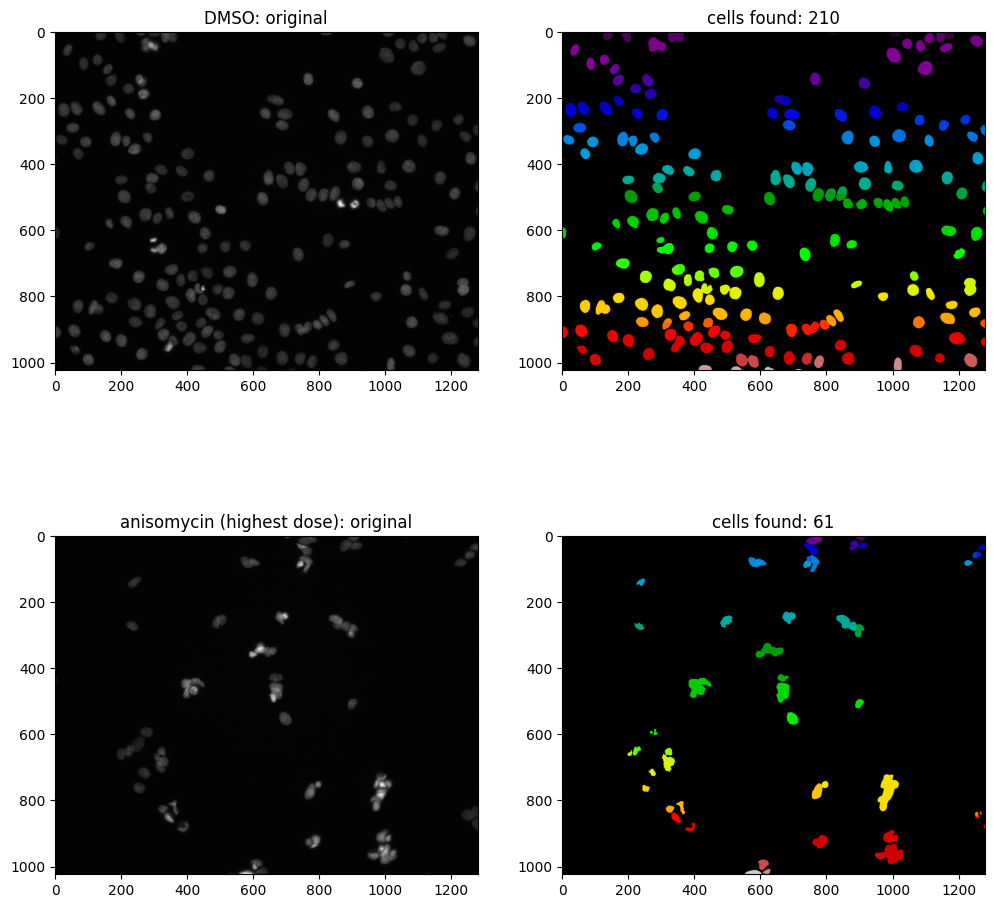

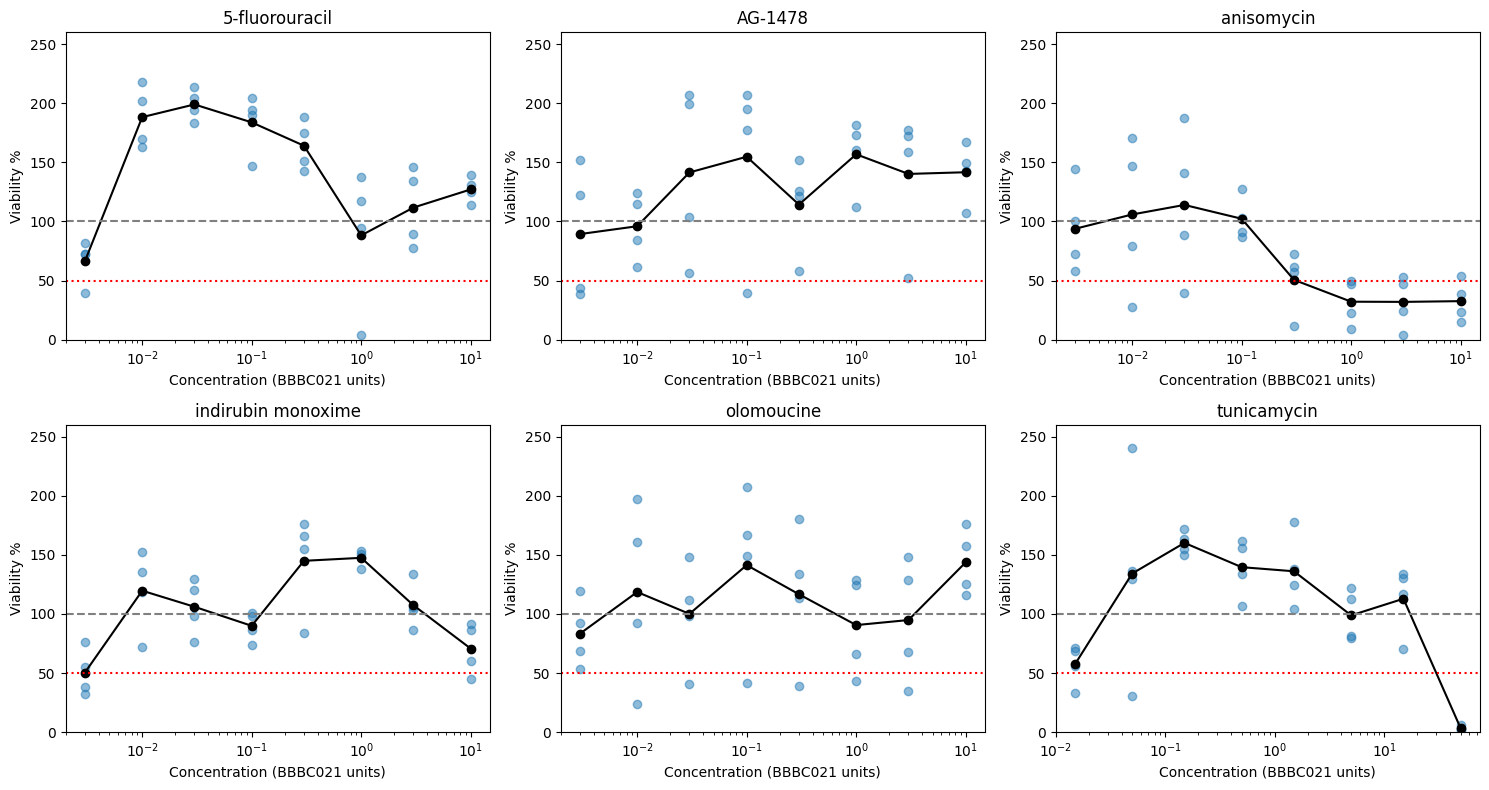

In [2]:
ctrl = sub[sub["Image_Metadata_Compound"] == "DMSO"].iloc[0]
drug = sub[sub["Image_Metadata_Compound"] == "anisomycin"].sort_values("Image_Metadata_Concentration").iloc[-1]
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
for i, (row, name) in enumerate([(ctrl, "DMSO"), (drug, "anisomycin (highest dose)")]):
    img, lab = count_nuclei(path_map[row["Image_FileName_DAPI"]])
    ax[i, 0].imshow(img, cmap="gray"); ax[i, 0].set_title(f"{name}: original")
    ax[i, 1].imshow(lab, cmap="nipy_spectral"); ax[i, 1].set_title(f"cells found: {lab.max()}")
plt.savefig("segmentation_example.png", dpi=150); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, comp in zip(axes.ravel(), CHOSEN):
    d = sub[sub["Image_Metadata_Compound"] == comp]
    ax.scatter(d["Image_Metadata_Concentration"], d["viability"], alpha=0.5)
    g = d.groupby("Image_Metadata_Concentration")["viability"].mean()
    ax.plot(g.index, g.values, "ko-")
    ax.axhline(100, color="gray", ls="--"); ax.axhline(50, color="red", ls=":")
    ax.set_xscale("log"); ax.set_ylim(0, 260); ax.set_title(comp)
    ax.set_xlabel("Concentration (BBBC021 units)"); ax.set_ylabel("Viability %")
plt.tight_layout(); plt.savefig("overview_all_compounds.png", dpi=150); plt.show()